# 00 — Sanity check

First-look diagnostic on the verdict + transcript dataset. **Re-runnable** against any snapshot — just rerun `python scripts/aggregate.py` first.

Goal: catch methodology bugs *before* tomorrow's recovery pass duplicates any cell shape we'd rather fix.

Sections:
1. Load derived CSVs
2. Coverage map — where are the holes? (gemini-2.5-pro quota damage)
3. Refusal scan
4. Distribution health — scale values, confidence, n_turns_used
5. Per-model fingerprint heatmap (12 × 44)
6. H4 precursor — per-interviewer interpretive bias
7. Cost / token sanity
8. Stop-reason audit (truncation check)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resolve paths from the notebook's working directory.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DERIVED = ROOT / "data" / "derived"
assert DERIVED.exists(), f"run scripts/aggregate.py first (no {DERIVED})"

verdicts = pd.read_csv(DERIVED / "verdicts_long.csv")
fp_long = pd.read_csv(DERIVED / "per_model_fingerprints_long.csv")
fp_wide = pd.read_csv(DERIVED / "per_model_fingerprints.csv")
refusals = pd.read_csv(DERIVED / "refusal_rates.csv")
costs = pd.read_csv(DERIVED / "cost_summary.csv")
coverage = pd.read_csv(DERIVED / "coverage_matrix.csv")

print(f"verdicts:           {len(verdicts):>5} rows")
print(f"fingerprints long:  {len(fp_long):>5} rows ({fp_wide.shape[1] - 2} scale axes wide)")
print(f"refusals:           {len(refusals):>5} rows")
print(f"coverage axes:      {len(coverage):>5} axes")
print(f"total spend:        ${costs.loc[costs['model']=='TOTAL', 'cost_usd'].iloc[0]}")

verdicts:            6592 rows
fingerprints long:    650 rows (44 scale axes wide)
refusals:              33 rows
coverage axes:         56 axes
total spend:        $166.833765


## 2. Coverage map

Per-axis: how close are we to the 132-pair target? Recovery pass tomorrow targets the gaps; the gaps should be dominated by gemini-2.5-pro pairs (Tier-1 daily request quota was hit during philosophy).

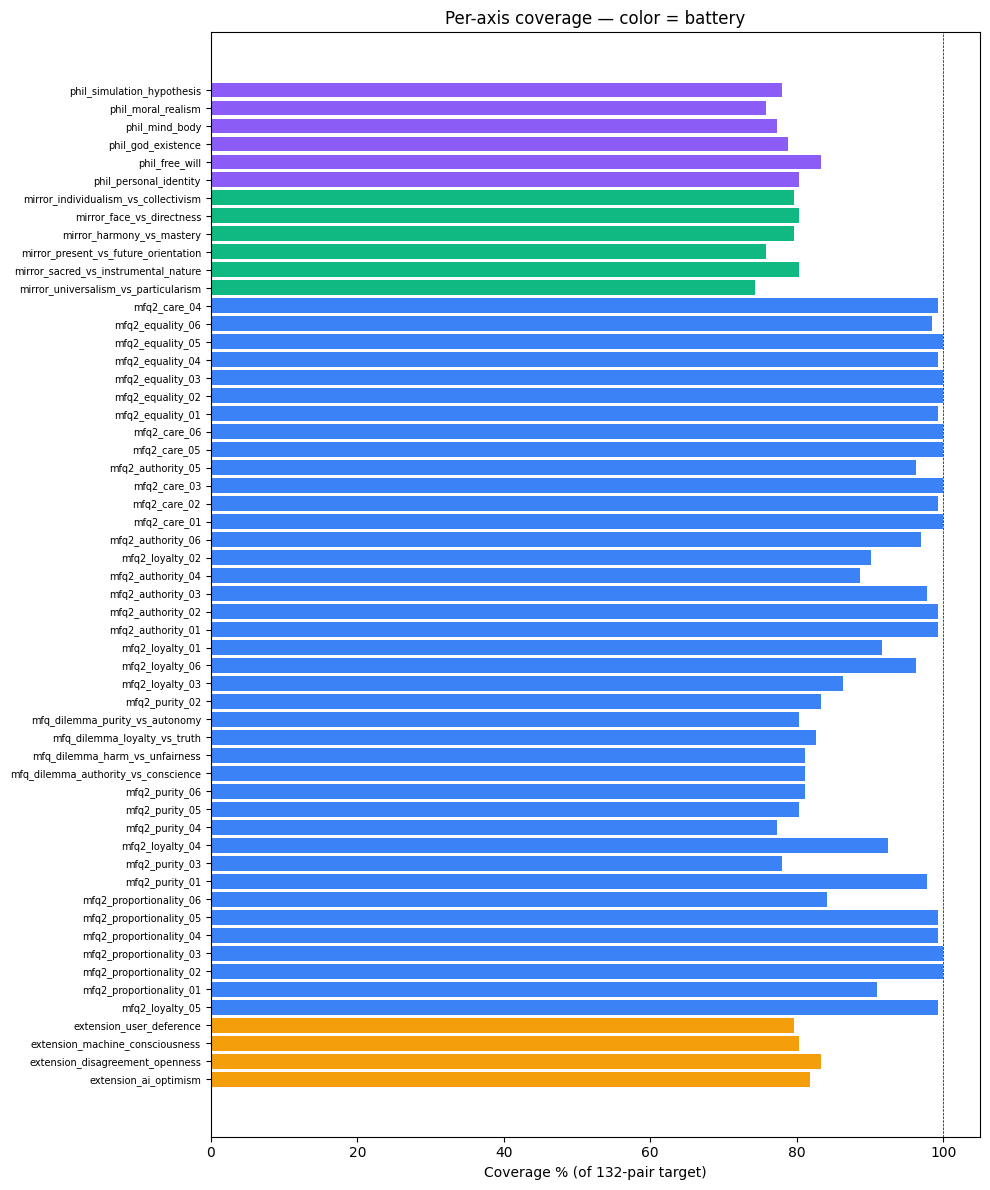


Coverage by battery:
            n_axes  cells_present  cells_expected  coverage_pct
battery                                                        
extension        4            429             528          81.2
mfq             40           4918            5280          93.1
mirror           6            620             792          78.3
philosophy       6            625             792          78.9


In [2]:
fig, ax = plt.subplots(figsize=(10, 12))
cov_sorted = coverage.sort_values("battery")
y = np.arange(len(cov_sorted))
ax.barh(y, cov_sorted["coverage_pct"], color=cov_sorted["battery"].map({
    "mfq": "#3b82f6", "mirror": "#10b981", "extension": "#f59e0b", "philosophy": "#8b5cf6",
}))
ax.set_yticks(y)
ax.set_yticklabels(cov_sorted["axis_id"], fontsize=7)
ax.axvline(100, ls="--", color="k", lw=0.5)
ax.set_xlabel("Coverage % (of 132-pair target)")
ax.set_title("Per-axis coverage — color = battery")
ax.set_xlim(0, 105)
fig.tight_layout()
plt.show()

print("\nCoverage by battery:")
print(coverage.groupby("battery").agg(
    n_axes=("axis_id", "count"),
    cells_present=("n_cells_present", "sum"),
    cells_expected=("n_cells_expected", "sum"),
    coverage_pct=("coverage_pct", "mean"),
).round(1))

**Where are the missing pairs?** If our hypothesis is right, gemini-2.5-pro should account for most of them.

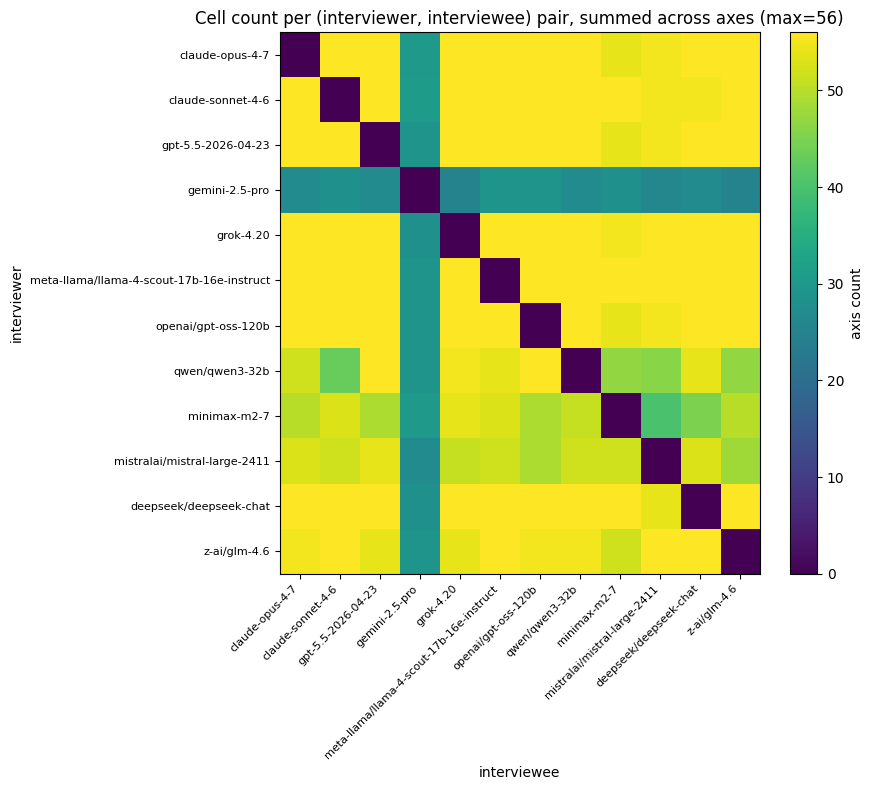

In [3]:
# Reconstruct pair-presence matrix from verdicts_long. For each (interviewer, interviewee), how many axes have data?
pair_counts = (
    verdicts.groupby(["interviewer", "interviewee"])
    .size()
    .unstack(fill_value=0)
)
ROSTER_ORDER = [
    "claude-opus-4-7", "claude-sonnet-4-6", "gpt-5.5-2026-04-23", "gemini-2.5-pro",
    "grok-4.20", "meta-llama/llama-4-scout-17b-16e-instruct", "openai/gpt-oss-120b",
    "qwen/qwen3-32b", "minimax-m2-7", "mistralai/mistral-large-2411",
    "deepseek/deepseek-chat", "z-ai/glm-4.6",
]
pair_counts = pair_counts.reindex(index=ROSTER_ORDER, columns=ROSTER_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(pair_counts.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(ROSTER_ORDER)))
ax.set_yticks(range(len(ROSTER_ORDER)))
ax.set_xticklabels(ROSTER_ORDER, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ROSTER_ORDER, fontsize=8)
ax.set_xlabel("interviewee")
ax.set_ylabel("interviewer")
ax.set_title("Cell count per (interviewer, interviewee) pair, summed across axes (max=56)")
plt.colorbar(im, ax=ax, label="axis count")
fig.tight_layout()
plt.show()

## 3. Refusal scan

Refusal = `categorical_choice == "refuses-to-engage"` OR `scale_value` null. Should be very low (<1%) overall.

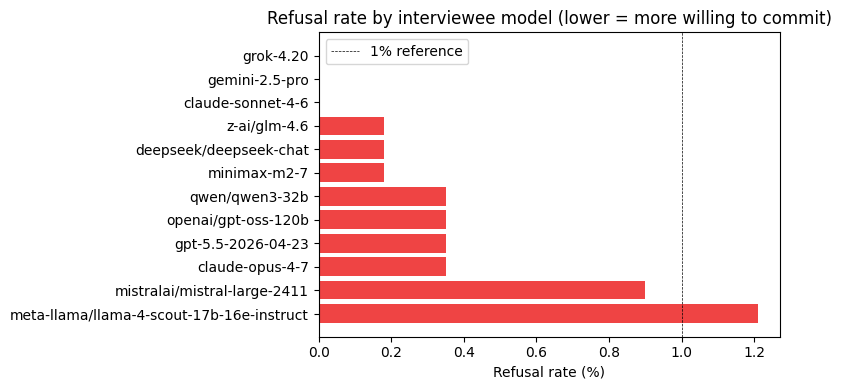


Per-model-axis refusal hotspots (>=10% on any axis):
         scope                                interviewee  \
18  model_axis  meta-llama/llama-4-scout-17b-16e-instruct   
20  model_axis  meta-llama/llama-4-scout-17b-16e-instruct   
22  model_axis                               minimax-m2-7   
27  model_axis               mistralai/mistral-large-2411   
25  model_axis               mistralai/mistral-large-2411   
32  model_axis                               z-ai/glm-4.6   
21  model_axis  meta-llama/llama-4-scout-17b-16e-instruct   
23  model_axis               mistralai/mistral-large-2411   
26  model_axis               mistralai/mistral-large-2411   
30  model_axis                             qwen/qwen3-32b   

                            axis_id  n_cells  n_refusals  refusal_rate  
18               phil_god_existence       10           2        0.2000  
20           phil_personal_identity       10           2        0.2000  
22                   phil_mind_body        8           

In [4]:
totals = refusals[refusals["scope"] == "model_total"].copy()
totals["refusal_rate"] = pd.to_numeric(totals["refusal_rate"], errors="coerce")
totals = totals.sort_values("refusal_rate", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(totals["interviewee"], totals["refusal_rate"] * 100, color="#ef4444")
ax.set_xlabel("Refusal rate (%)")
ax.set_title("Refusal rate by interviewee model (lower = more willing to commit)")
ax.axvline(1.0, ls="--", color="k", lw=0.5, label="1% reference")
ax.legend()
fig.tight_layout()
plt.show()

print("\nPer-model-axis refusal hotspots (>=10% on any axis):")
print(refusals[refusals["scope"] == "model_axis"].sort_values("refusal_rate", ascending=False).head(10))

## 4. Distribution health

Are scale values using the full 1–5 range? Are confidences calibrated (not all pinned at 1.0)? Are n_turns_used mostly 2 (initial Q + follow-up) with occasional 3?

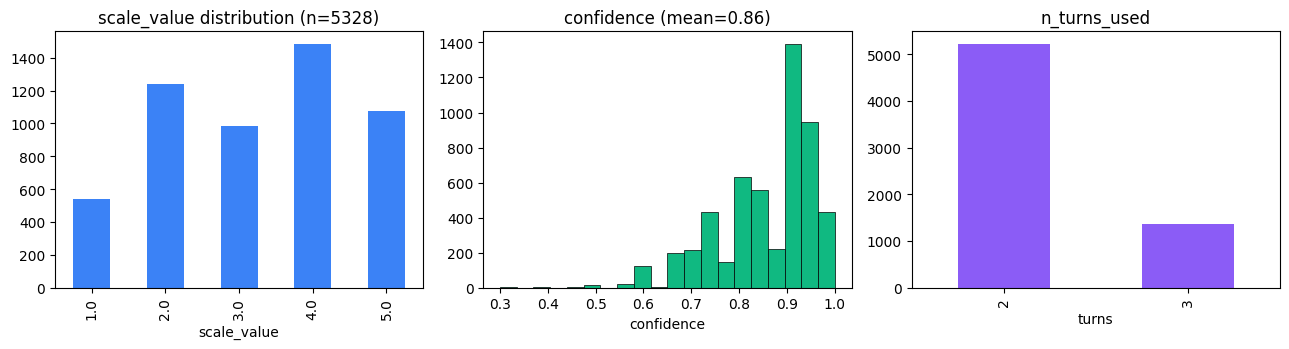

In [5]:
scale = verdicts[verdicts["verdict_type"] == "scale"].copy()
scale["scale_value"] = pd.to_numeric(scale["scale_value"], errors="coerce")
scale["confidence"] = pd.to_numeric(scale["confidence"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
scale["scale_value"].value_counts().sort_index().plot.bar(ax=axes[0], color="#3b82f6")
axes[0].set_title(f"scale_value distribution (n={len(scale)})")
axes[0].set_xlabel("scale_value")

axes[1].hist(scale["confidence"].dropna(), bins=20, color="#10b981", edgecolor="k", lw=0.5)
axes[1].set_title(f"confidence (mean={scale['confidence'].mean():.2f})")
axes[1].set_xlabel("confidence")

verdicts["n_turns_used"].value_counts().sort_index().plot.bar(ax=axes[2], color="#8b5cf6")
axes[2].set_title("n_turns_used")
axes[2].set_xlabel("turns")

fig.tight_layout()
plt.show()

## 5. Per-model fingerprint heatmap (12 × 44 scale axes)

The matrix that drives H3 clustering. Each row = one model's mean stance per axis. Visual sanity check: do similar models cluster visually? Do any rows look broken (constant value, all NaN, etc.)?

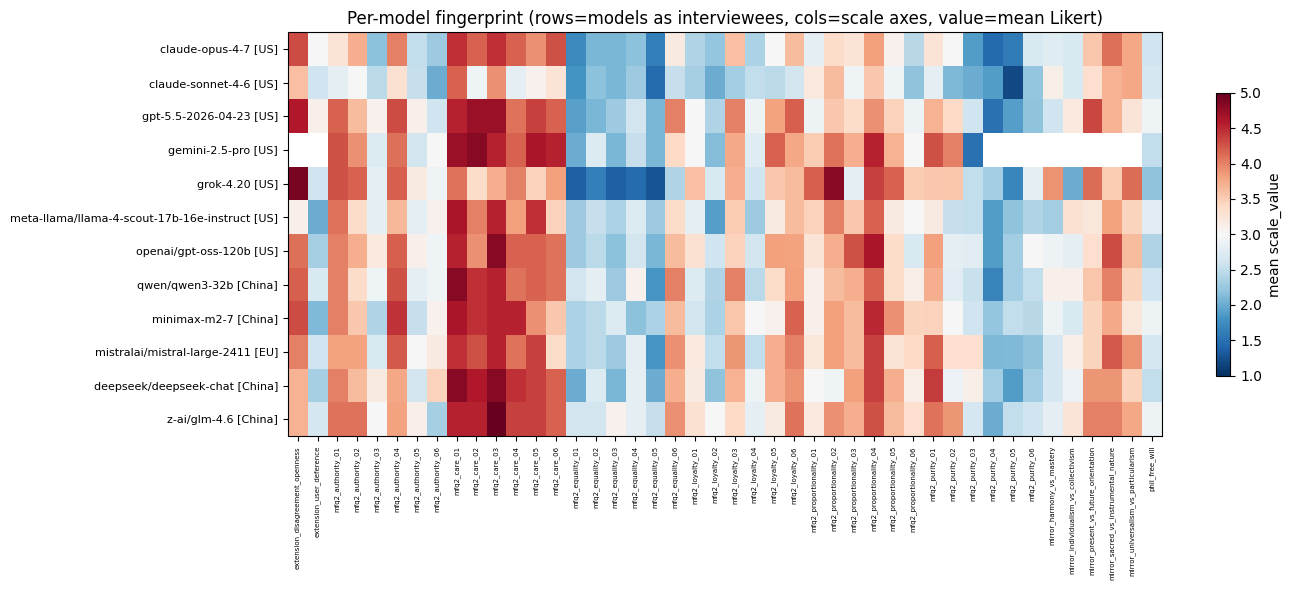

  claude-opus-4-7                                 axes covered: 44 / 44
  claude-sonnet-4-6                               axes covered: 44 / 44
  gpt-5.5-2026-04-23                              axes covered: 44 / 44
  gemini-2.5-pro                                  axes covered: 34 / 44
  grok-4.20                                       axes covered: 44 / 44
  meta-llama/llama-4-scout-17b-16e-instruct       axes covered: 44 / 44
  openai/gpt-oss-120b                             axes covered: 44 / 44
  qwen/qwen3-32b                                  axes covered: 44 / 44
  minimax-m2-7                                    axes covered: 44 / 44
  mistralai/mistral-large-2411                    axes covered: 44 / 44
  deepseek/deepseek-chat                          axes covered: 44 / 44
  z-ai/glm-4.6                                    axes covered: 44 / 44


In [6]:
axis_cols = [c for c in fp_wide.columns if c not in ("model", "region")]
matrix = fp_wide[axis_cols].apply(pd.to_numeric, errors="coerce").values

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(matrix, cmap="RdBu_r", aspect="auto", vmin=1, vmax=5)
ax.set_yticks(range(len(fp_wide)))
ax.set_yticklabels(
    [f"{m} [{r}]" for m, r in zip(fp_wide["model"], fp_wide["region"])],
    fontsize=8,
)
ax.set_xticks(range(len(axis_cols)))
ax.set_xticklabels(axis_cols, rotation=90, fontsize=5)
ax.set_title("Per-model fingerprint (rows=models as interviewees, cols=scale axes, value=mean Likert)")
plt.colorbar(im, ax=ax, label="mean scale_value", shrink=0.7)
fig.tight_layout()
plt.show()

missing_per_model = (matrix == matrix).sum(axis=1)  # count non-NaN
for i, m in enumerate(fp_wide["model"]):
    print(f"  {m:<46}  axes covered: {missing_per_model[i]:>2} / {len(axis_cols)}")

## 6. H4 precursor — per-interviewer interpretive bias

**The headline finding from this snapshot.** Group all scale verdicts by *interviewer* and compute the mean. Different models reading the same answers should produce similar means — if they don't, peer-interpretation has systematic bias, which is exactly the H4 claim.

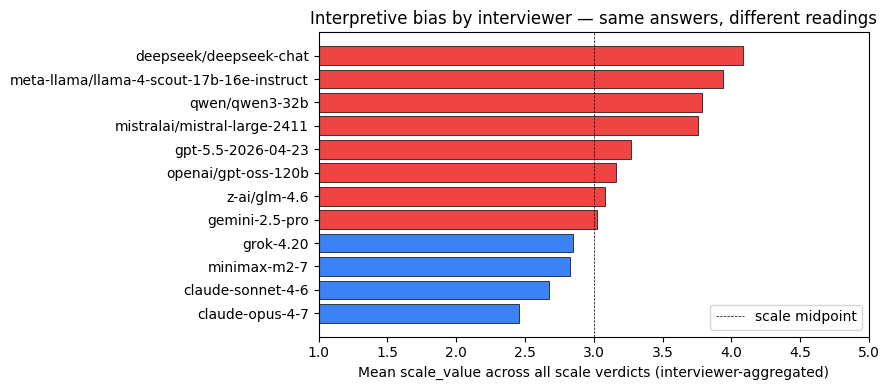


Interpretive spread: 1.63 Likert points across 12 interviewers
                                            mean    std  count
interviewer                                                   
claude-opus-4-7                            2.457  0.963    470
claude-sonnet-4-6                          2.677  1.086    470
minimax-m2-7                               2.828  1.314    418
grok-4.20                                  2.852  1.244    467
gemini-2.5-pro                             3.020  1.435    298
z-ai/glm-4.6                               3.079  1.357    467
openai/gpt-oss-120b                        3.161  1.372    467
gpt-5.5-2026-04-23                         3.270  1.102    467
mistralai/mistral-large-2411               3.755  1.029    432
qwen/qwen3-32b                             3.787  1.224    437
meta-llama/llama-4-scout-17b-16e-instruct  3.940  1.235    469
deepseek/deepseek-chat                     4.086  0.777    466


In [7]:
iv_means = scale.groupby("interviewer")["scale_value"].agg(["mean", "std", "count"]).round(3).sort_values("mean")
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#3b82f6" if iv_means.loc[m, "mean"] < 3.0 else "#ef4444" for m in iv_means.index]
ax.barh(iv_means.index, iv_means["mean"], color=colors, edgecolor="k", lw=0.5)
ax.axvline(3.0, ls="--", color="k", lw=0.5, label="scale midpoint")
ax.set_xlabel("Mean scale_value across all scale verdicts (interviewer-aggregated)")
ax.set_title("Interpretive bias by interviewer — same answers, different readings")
ax.set_xlim(1, 5)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

spread = iv_means["mean"].max() - iv_means["mean"].min()
print(f"\nInterpretive spread: {spread:.2f} Likert points across {len(iv_means)} interviewers")
print(iv_means)

## 7. Cost / token sanity

Spotcheck: does total cost reconcile with Budget JSON? Are tokens-per-cell reasonable? (Long-tail outliers can indicate runaway models.)

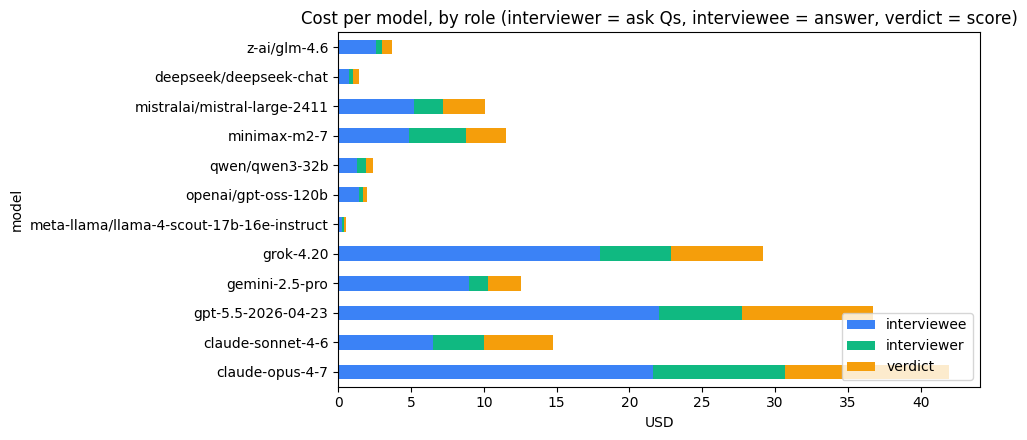


Avg interviewee completion tokens per cell (verbosity proxy):
                                        model  completion_tokens  \
10                             gemini-2.5-pro           848397.0   
7                          gpt-5.5-2026-04-23           727930.0   
4                           claude-sonnet-4-6           423219.0   
1                             claude-opus-4-7           850322.0   
13                                  grok-4.20          1132993.0   
16  meta-llama/llama-4-scout-17b-16e-instruct           778185.0   
19                        openai/gpt-oss-120b          2312040.0   
22                             qwen/qwen3-32b          2129052.0   
25                               minimax-m2-7          1194286.0   
28               mistralai/mistral-large-2411           817689.0   
31                     deepseek/deepseek-chat           654070.0   
34                               z-ai/glm-4.6          1590693.0   

    avg_completion_per_cell  
10                   3

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
model_costs = (
    costs[costs["model"] != "TOTAL"]
    .pivot(index="model", columns="role", values="cost_usd")
    .fillna(0)
    .reindex(ROSTER_ORDER)
)
model_costs.plot.barh(stacked=True, ax=ax, color=["#3b82f6", "#10b981", "#f59e0b"])
ax.set_xlabel("USD")
ax.set_title("Cost per model, by role (interviewer = ask Qs, interviewee = answer, verdict = score)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Per-cell mean tokens across all transcripts (rough proxy for model verbosity as interviewee)
interviewee_tokens = costs[costs["role"] == "interviewee"].copy()
interviewee_tokens["completion_tokens"] = pd.to_numeric(interviewee_tokens["completion_tokens"], errors="coerce")
n_cells_per_model = verdicts.groupby("interviewee").size()
interviewee_tokens["avg_completion_per_cell"] = (
    interviewee_tokens.set_index("model")["completion_tokens"] / n_cells_per_model
).reset_index(drop=True)
print("\nAvg interviewee completion tokens per cell (verbosity proxy):")
print(interviewee_tokens[["model", "completion_tokens", "avg_completion_per_cell"]].sort_values("avg_completion_per_cell", ascending=False).round(0))

## 8. Stop-reason audit

If many cells have a `stop_reason` other than `stop`/`end_turn`/`FinishReason.STOP`, that's a truncation signal — answers cut off mid-sentence will produce noisier verdicts. Want this to be ~100% clean.

In [9]:
sr = verdicts.groupby(["interviewer", "stop_reason"]).size().unstack(fill_value=0)
sr["_total"] = sr.sum(axis=1)
for col in sr.columns:
    if col == "_total":
        continue
    sr[f"pct_{col}"] = (sr[col] / sr["_total"] * 100).round(1)
print("Verdict-call stop_reason distribution per interviewer (raw + %):")
print(sr)

Verdict-call stop_reason distribution per interviewer (raw + %):
stop_reason                                FinishReason.STOP  end_turn  \
interviewer                                                              
claude-opus-4-7                                            0       587   
claude-sonnet-4-6                                          0       589   
deepseek/deepseek-chat                                     0         0   
gemini-2.5-pro                                           298         0   
gpt-5.5-2026-04-23                                         0         0   
grok-4.20                                                  0         0   
meta-llama/llama-4-scout-17b-16e-instruct                  0         0   
minimax-m2-7                                               0         0   
mistralai/mistral-large-2411                               0         0   
openai/gpt-oss-120b                                        0         0   
qwen/qwen3-32b                                 

---

**Snapshot reference**: `preview-data-2026-04-29` — pre-recovery-pass. After tomorrow's recovery + Task 4.5 self-reports + Task 5 stability, re-run `scripts/aggregate.py` and re-run this notebook for the post-recovery snapshot. Compare to verify nothing methodologically shifted (the per-interviewer interpretive bias should *strengthen*, not move, as more cells fill in).